In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import plotly.graph_objects as go
from functions_continuous_hmm import *

snp = pd.read_csv(Path.cwd() / "investing_dot_com_transformed" / "CSPX ETF Stock Price History.csv")
china = pd.read_csv(Path.cwd() / "investing_dot_com_transformed" / "CNYA ETF Stock Price History.csv")
em = pd.read_csv(Path.cwd() / "investing_dot_com_transformed" / "EIMI ETF Stock Price History.csv")
gold = pd.read_csv(Path.cwd() / "investing_dot_com_transformed" / "XAD5 ETF Stock Price History.csv")
india = pd.read_csv(Path.cwd() / "investing_dot_com_transformed" / "INR ETF Stock Price History.csv")
mscieurope = pd.read_csv(Path.cwd() / "investing_dot_com_transformed" / "XMEU ETF Stock Price History.csv")
smallcapeurope = pd.read_csv(Path.cwd() / "investing_dot_com_transformed" / "SXRJ ETF Stock Price History.csv")
ussmallcap = pd.read_csv(Path.cwd() / "investing_dot_com_transformed" / "CUSS ETF Stock Price History.csv")
silver = pd.read_csv(Path.cwd() / "investing_dot_com_transformed" / "SSLN ETF Stock Price History.csv")

dfs = [snp, china, em, gold, india, mscieurope, smallcapeurope, ussmallcap, silver]

N = len(dfs)
T = len(dfs[0]) - 1

dfs = [df[["Date", "Price", "Vol."]] for df in dfs]

# Convert Date to datetime
dfs_new = []
for df in dfs:
    df["Date"] = pd.to_datetime(df["Date"])
    dfs_new.append(df)

dfs = dfs_new

names = ["snp", "china", "em", "gold", "india", "mscieurope",
         "smallcapeurope", "ussmallcap", "silver"]

dfs_renamed = []

for name, df in zip(names, dfs):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    
    df = df.rename(columns={
        "Price": f"Price_{name}",
        "Vol.": f"Vol_{name}"
    })
    
    dfs_renamed.append(df)

dfs = dfs_renamed

# Merge all on Date
df_merged = dfs[0]
for df in dfs[1:]:
    df_merged = df_merged.merge(df, on="Date", how="inner", suffixes=("", "_x"))

# Sort by date
df_merged = df_merged.sort_values("Date")

def correct_volume(vol_value):
    if isinstance(vol_value, (float, int)):
        return vol_value
    if vol_value[-1] == "K":
        return 1000 * float(vol_value[:-1])
    if vol_value[-1] == "M":
        return 1_000_000 * float(vol_value[:-1])
    return float(vol_value)

df_merged = df_merged.set_index("Date")

price_cols = [col for col in df_merged.columns if col.startswith("Price_")]
vol_cols = [col for col in df_merged.columns if col.startswith("Vol_")]

prices_df = df_merged[price_cols].apply(pd.to_numeric, errors="coerce")
volumes_df = df_merged[vol_cols].copy()

for col in volumes_df.columns:
    volumes_df[col] = volumes_df[col].apply(correct_volume)

volumes_df = volumes_df.fillna(0.0)

prices = prices_df.values  # shape: (T+1, N)
volumes = volumes_df.values  # shape: (T+1, N)

returns = prices[1:] / prices[:-1] - 1
prices = prices[1:]
volumes = volumes[1:]         # (T, N)
dates = df_merged.index[1:]       # (T,)
print(returns.shape, prices.shape, volumes.shape, dates.shape)

(2413, 9) (2413, 9) (2413, 9) (2413,)


In [2]:
PCT_TRAINING_DATA = 0.9
T_total = returns.shape[0]
T_train = int(T_total * PCT_TRAINING_DATA)
T_test = T_total - T_train
returns_training = returns[:T_train]
returns_testing = returns[T_train:]
returns


array([[-0.00268762,  0.00476948, -0.00737403, ..., -0.01416053,
        -0.00453677,  0.00313631],
       [-0.00461235,  0.02531646, -0.00288898, ..., -0.01095008,
         0.00255857, -0.01034151],
       [-0.00203051, -0.02777778, -0.00372517, ..., -0.000521  ,
        -0.00514395, -0.00194411],
       ...,
       [-0.00759045, -0.01013514, -0.00854345, ...,  0.00134771,
        -0.00446502, -0.02963486],
       [-0.0127289 , -0.01194539, -0.01723413, ..., -0.02706744,
        -0.01312292, -0.08707508],
       [-0.00528727, -0.01208981, -0.01796407, ..., -0.01629265,
        -0.00488133, -0.00477897]], shape=(2413, 9))

Compute returns and cumulative returns per asset

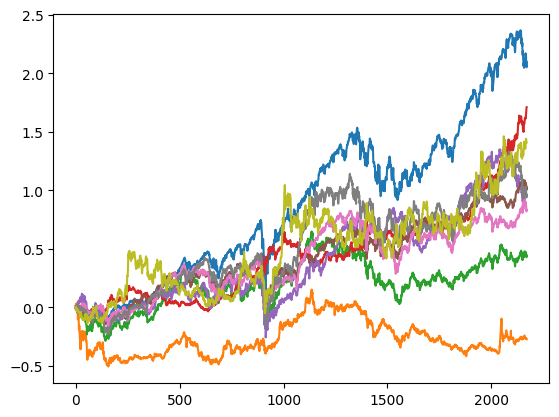

In [3]:
import matplotlib.pyplot as plt

cum_returns_train = (pd.DataFrame(returns_training) + 1).cumprod() - 1

fig, ax = plt.subplots()
N = returns_training.shape[1]
for i in range(N):
    ax.plot(cum_returns_train.values[:, i])


plt.show()

Because right now we obviously don't have access to the true regime transition probabilities (we're dealing with real data now), we will only be able to estimate the transition probabilities by using k-means clustering.

In [5]:
def k_means(data, k):
    # data: np-array of vectors (points), shape (n_vectors, vector_dim)
    # k: amount of clusters

    # data size: (n_points, vector_dim)

    center_indices = np.random.randint(0, len(data), size=(1,k)) # (1, k)
    centers = np.array([data[i] for i in center_indices]).reshape((k, data.shape[1])) # (k, vector_dim)
    
    clusters = [[] for _ in range(k)] # (k, n_vectors_to_cluster, vector_dim)
    
    while True:
        new_clusters = clusters
        """
        for every point: determine dist to every cluster
        categorize points based on dist (take smallest)
        redetermine clusters
        """

        labels = [] # length n_vectors

        # determine clusters
        for vector in data:
            # vector: (1, vector_dim)

            # distances for vector to every cluster vector
            # (1, k)

            distances = np.array([np.linalg.norm(vector - core) for core in centers])
            idx = np.argmin(distances)
            new_clusters[idx].append(vector) # list of length k
            labels.append(int(idx))

        if new_clusters == clusters:
            return clusters, centers, labels

        # determine new centers
        for k_idx, cluster in enumerate(clusters):
            # cluster: list of vectors
            avg_vector = np.zeros(data.shape[1])
            for vec in cluster:
                # vec: (vector_dim)
                avg_vector += vec
            avg_vector /= len(cluster)
            centers[k_idx,:] = avg_vector

In [6]:
M = 3 # number of states, we take 3 here just like in simulated environment
T = returns_training.shape[0]

calc_volatility = pd.DataFrame(returns_training).rolling(30, min_periods=0).std()
calc_volatility.iloc[0] = calc_volatility.iloc[1]
clusters, centers, est_regimes = k_means(calc_volatility.values, M)
est_regimes = np.array(est_regimes)

mus = np.empty((M, N))

# mus: shape M x N
# clusters: shape M x (num_vectors_in_cluster) x N
Sigma = np.empty((M, N, N))

eps = 1e-7

for m in range(M):
    # find returns corresponding to regime m
    reg_returns = returns_training[est_regimes == m, :]
    mus[m, :] = reg_returns.mean(axis=0)
    Sigma[m] = np.cov(reg_returns, rowvar=False)
    Sigma[m] = 0.5 * (Sigma[m] + Sigma[m].T)
    Sigma[m] += eps * np.eye(N)

# construct the estimated version of A (using estimated regime sequence)
A = np.zeros((M, M))
pi = np.zeros(M)
for m in range(len(est_regimes[:-1])):
    cur_est_regime = est_regimes[m]
    next_est_regime = est_regimes[m + 1]
    A[cur_est_regime, next_est_regime] += 1
    pi[cur_est_regime] += 1
A_sum = A.sum(axis=1)
for n in range(M):
    A[n, :] /= A_sum[n]
pi /= pi.sum()

print(A)

[[0.96835443 0.00271248 0.02893309]
 [0.01351351 0.9527027  0.03378378]
 [0.0371179  0.00436681 0.95851528]]


In [7]:
for m in range(M):
    print('number of samples for regime', m, ':')
    print(len(returns_training[est_regimes == m, :]))

number of samples for regime 0 :
1107
number of samples for regime 1 :
148
number of samples for regime 2 :
916


Run the algorithm

In [8]:

print('sanity check: det of cov of all returns')
cov = np.cov(returns, rowvar=False)
print(np.linalg.det(cov))
print('eigenvalues:')
print(np.linalg.eigvalsh(cov))
print('conditioning number:')
print(np.linalg.cond(cov))

sanity check: det of cov of all returns
1.3629525810337243e-37
eigenvalues:
[1.53696766e-05 1.91056661e-05 3.27897672e-05 3.54489783e-05
 5.09248854e-05 1.18236300e-04 2.16223483e-04 3.92714887e-04
 7.80999333e-04]
conditioning number:
50.814298274780946


In [9]:

pct_change_ll_tol = 1e-06
n_attempts = 20
max_attempt_per_iter = 30

ll_list = []

# these will store data from every run
# stucture: list of floats (one per attempt, not one per iteration)
pct_states_matched_viterbi = []
frac_correct_states_predicted_list = []
all_predicted_obs = []

params_keep = []

tt = []

for attempt in range(n_attempts):

    prev_ll = 1.0
    log_ll = 2.0

    # initialize parameters

    # choose diagonal values of A randomly
    A_est = A.copy() + np.random.normal(0, 0.25, A.shape)
    A_est = np.clip(A_est, a_min=0.01, a_max=0.99)
    for k in range(A_est.shape[0]):
        A_est[k,:] = A_est[k,:] / np.sum(A_est[k,:])
    loga = np.log(A_est)

    pi_est = pi.copy() + np.random.normal(0, 0.15, pi.shape)
    pi_est = np.clip(pi_est, a_min=0.01, a_max=0.99)
    pi_est /= np.sum(pi_est)
    logpi = np.log(pi_est)

    logb = compute_b(mus, Sigma, returns_training, T_train, M)
    B_est = np.exp(logb)

    # store some metrics for each iterion step
    this_diff_norms_A = []
    this_diff_norms_B = []
    this_diff_norms_pi = []
    this_attempt_ll_list = []

    this_attempt_count = 0

    while abs(prev_ll - log_ll) / abs(prev_ll) > pct_change_ll_tol and this_attempt_count < max_attempt_per_iter:
        prev_ll = log_ll

        # E step
        logalpha, scaling = forward(loga, logb, T_train, M, logpi)
        logbeta = backward(loga, logb, T_train, M)
        loggamma = compute_gamma(logalpha, logbeta, T_train, M)
        logxi = compute_xi(logalpha, logbeta, loga, logb, T_train, M)

        # M step
        loga = compute_a(loggamma, logxi, T_train, M)
        mus, Sigma = compute_mus_sigmas(loggamma, returns_training, T_train, M, N)

        logb = compute_b(mus, Sigma, returns_training, T_train, M)
        logpi = loggamma[0, :]

        # storing metrics for each iteration
        log_ll = np.sum(scaling)
        this_attempt_ll_list.append(log_ll)
        this_attempt_count += 1

    
    A_est = np.exp(loga)
    A_est /= A_est.sum(axis=1, keepdims=True)
    B_est = np.exp(logb)
    B_est /= B_est.sum(axis=1, keepdims=True)
    pi_est = np.exp(logpi)
    pi_est /= pi_est.sum()

    params_keep.append((A_est, B_est, pi_est, mus, Sigma))

    A_est = np.clip(A_est, 1e-10, 1)
    B_est = np.clip(B_est, 1e-10, 1)

    # store data from this attempt
    ll_list.append(this_attempt_ll_list)

best_attempt = np.argmax([x[-1] for x in ll_list])
A_best, B_best, pi_best, mu_best, sigma_best = params_keep[best_attempt]
        

In [ ]:
print('A best:'); print(A_best)
print('B best:'); print(B_best)
print('pi best:'); print(pi_best)

A best:
[[0.62008851 0.06188144 0.31803006]
 [0.01405987 0.97179995 0.01414018]
 [0.01089872 0.01060796 0.97849332]]
B best:
[[0.33335112 0.33321495 0.33343394]
 [0.33335406 0.33319465 0.33345129]
 [0.33334436 0.33325676 0.33339888]
 ...
 [0.33334679 0.33324408 0.33340913]
 [0.33334923 0.33322882 0.33342195]
 [0.33335242 0.33319731 0.33345027]]
pi best:
[0.03546856 0.48474295 0.47978849]


Plot log likelyhoods for each attempt

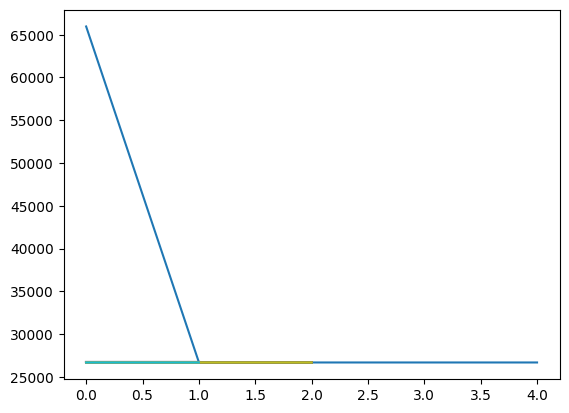

In [ ]:

import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for i in range(n_attempts):
    ax.plot(list(range(len(ll_list[i]))), ll_list[i])


plt.show()

Estimate regime distribution across time series

In [ ]:
regime_prob_vectors = np.empty((returns_testing.shape[0], M))
regime_prob_vectors[0,:] = pi_best * B_best[0,:]
for t in range(1, returns_testing.shape[0]):
    for k in range(M):
        regime_prob_vectors[t,k] = B_best[t,k] * np.dot(
            regime_prob_vectors[t-1,:], A_best[:,k]
        )
    regime_prob_vectors[t] /= np.sum(regime_prob_vectors[t])

pred_returns = np.empty((returns_testing.shape))
for t in range(returns_testing.shape[0]):
    pred_returns[t,:] = regime_prob_vectors[t] @ mu_best

Plot estimated (cumulative) returns (from previous block) with actual returns (from testing set)

In [ ]:
cum_pred_returns = np.cumprod(1 + pred_returns) - 1
cum_returns_test = np.cumprod(1 + returns_testing) - 1

fig = go.Figure()
L = list(range(len(returns_testing)))
fig.add_trace(go.Scatter(x=L, y=cum_pred_returns, name="predicted returns"))
fig.add_trace(go.Scatter(x=L, y=cum_returns_test, name="actual returns"))

fig.show()
